# Проект "Проверка гипотез и A/B анализ"

# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Часть 1. Проверка гипотезы в Python по данным Яндекс-книг и составление аналитической записки


- Автор: Денисова Валерия
- Дата: 09.04.2026

## Цель и задачи 
### Цель: 
Проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. 

### Задачи:
- Загрузить данные и познакомиться с ними.
- Проверить корректность данных, сравнить группы.
- Выбрать подходящий статистический тест и провести его.
- Сделать выводы.

## Описание данных

Датасет `yandex_knigi_data.csv`
- `Unnamed: 0` - порядковый номер строки
- `city` - город
- `puid` - идентификатор пользователя
- `hours` - сумма часов активности пользователя

## Содержимое проекта
1. Загрузка данных и знакомство с ними.
2. Проверка корректности данных, сравнение групп.
3. Проведение статистического теста.
4. Аналитическая записка.

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [34]:
# импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

In [35]:
# загружаем данные
try:
    df = pd.read_csv('/datasets/yandex_knigi_data.csv')
except:
    df = pd.read_csv('yandex_knigi_data.csv')

In [36]:
# считаем размер датасета
f'Датафрейм содержит {df.shape[0]} строк.'

'Датафрейм содержит 8784 строк.'

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [38]:
# выводим первые 5 строк датафрейма
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


Столбец `Unnamed: 0` не несет полезной функции для нас, поэтому удалим его.

In [39]:
# удаляем лишний столбец
df = df.drop('Unnamed: 0', axis = 1)

## 2. Проверка гипотезы в Python

Проверим наличие дубликатов в идентификаторах пользователей.


In [40]:
df['puid'].duplicated().sum()

np.int64(244)

В идентификаторах было найдено 244 дубликата. Удалим их.

In [41]:
df = df[~df['puid'].duplicated()]
f'Теперь общее количество пользователей {df.shape[0]}.'

'Теперь общее количество пользователей 8540.'

Посмотрим на соотношение размеров групп.

In [42]:
len_a = df[df['city'] == 'Москва'].shape[0]
len_b = df[df['city'] == 'Санкт-Петербург'].shape[0]
print(f'Москва: {len_a}\nСанкт-Петербург: {len_b}\nСоотношение {round(len_b/len_a, 2)}')

Москва: 6234
Санкт-Петербург: 2306
Соотношение 0.37


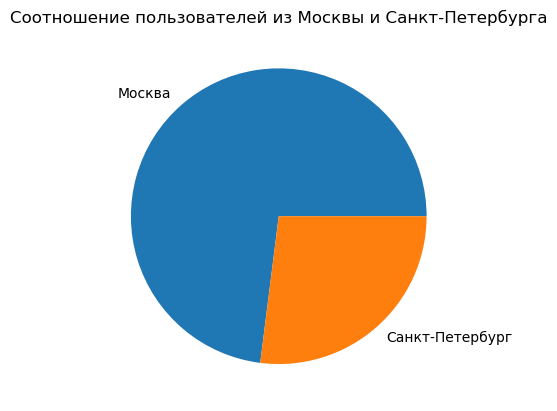

In [43]:
values = [len_a, len_b]
labels = ['Москва', 'Санкт-Петербург']
plt.pie(values, labels = labels)
plt.title('Соотношение пользователей из Москвы и Санкт-Петербурга')
plt.show()

Группы неравномерны по количетсву пользователей. Отношение размера выборки пользователей из Санкт-Петербурга к пользователям Москвы 37:100.

Далее посмотрим на распределение статистик в каждой группе.

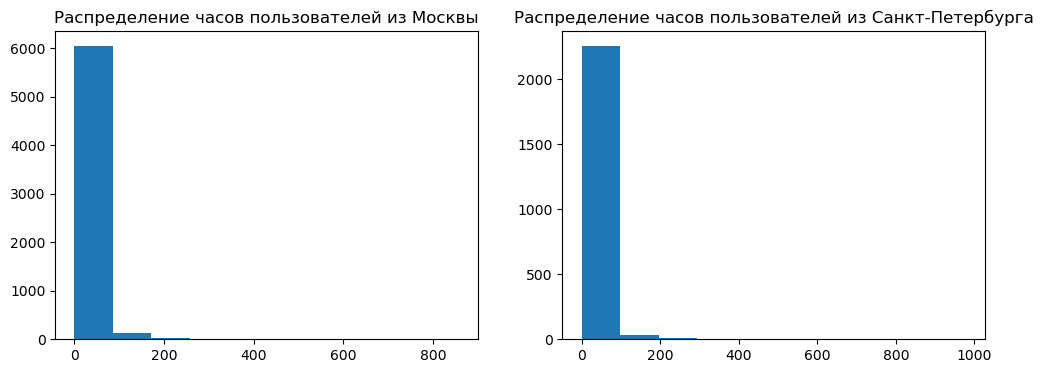

In [44]:
# делим на группы
moscow = df[df['city'] == 'Москва']
saintp = df[df['city'] == 'Санкт-Петербург']

# строим графики распределния
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

ax1.hist(moscow['hours'])
ax1.set_title('Распределение часов пользователей из Москвы')
ax2.hist(saintp['hours'])
ax2.set_title('Распределение часов пользователей из Санкт-Петербурга')
plt.show()

Форма распределения статистики схожа для пользователей из обоих городов. В основном количество часов активности находится в диапозоне от 0 до 100. Есть значительные выбросы (больше 600 часов).

Посчитаем выборочные дисперсии.

In [45]:
print(f'Выборочная дисперсия для Москвы: {moscow["hours"].var()}')
print(f'Выборочная дисперсия для Санкт-Петербурга: {saintp["hours"].var()}')

Выборочная дисперсия для Москвы: 1358.046536544389
Выборочная дисперсия для Санкт-Петербурга: 1586.5686735105946


Для выборки пользователей Санкт-Петербурга дисперсия больше на 200, чем для Москвы.

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Для проверки этой гипотезы будем использовать `тест Манна-Уитни`, так как в данных присутствуют серьезные выбросы, а также выборочные дисперсии сильно различаются.

Главная метрика - средняя активность пользователей в часах. Уровень значимости выберем равный `0.05`. 

In [46]:
# делим на группы
a = moscow['hours']
b = saintp['hours']

# устанавливаем уровень значимости
alpha = 0.05

test = mannwhitneyu (
    b, 
    a,
    alternative = 'greater')

p_value = test.pvalue
print(f'p-value: {p_value}')

if p_value<alpha:
    print('Отвергаем нулевую гипотезу.')
else:
    print('Не получилось отвергнуть нулевую гипотезу.')

p-value: 0.6189600878052618
Не получилось отвергнуть нулевую гипотезу.


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



Результаты анализа данных:
- Для проверки гипотезы был выбран тест Манна-Уитни, так как в выборках наблюдались выбросы и различные выборочные дисперсии. Уровень статистической значимости был выбран 0.05.
- p-value получился равным 0.6189600878052618.
- На основе полученного p-value не получилось отвергнуть нулевую гипотезу. Нельзя сказать, что средняя активность пользователей в часах в Санкт-Петербурге выше, чем в Москве.
- Такой результат может быть связан с тем, что пользователи из Москвы часто ездят на далекие расстояния на работу/учёбу, и у них есть много времени, чтобы прослушать книгу в пути. Также, на пользователей из Москвы и Санкт-Петербурга могут одинаково влиять соцсети, где рекламируются различные книги.
- У жителей этих городов действительно схожий образ жизни и бытовые привычки, это помогает логично объяснить результаты.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Цель и задачи 
### Цель:
Оценить корректность проведения А/B теста и проанализировать его результаты.
### Задачи:
1. Загрузить данные, оценить их целостность.
2. Оценить корректность проведения теста.
3. Проверить гипотезу.
4. Проанализировать результаты.

## Описание данных
Датасет `ab_test_participants.csv`:
- user_id — идентификатор пользователя;
- group — группа пользователя;
- ab_test — название теста;
- device — устройство, с которого происходила регистрация.

Датасет `ab_test_events`:
- user_id — идентификатор пользователя;
- event_dt — дата и время события;
- event_name — тип события;
- details — дополнительные данные о событии.

## Содержимое 
1. Загрузка данных, оценка целостности.
2. Оценка корректности проведения теста.
3. Проверка гипотезы.
4. Анализ результатов А/В тестирования.

## 2. Загрузите данные, оцените их целостность.


In [47]:
# загружаем данные 
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

Оценим данные в датасете `participants`.

In [48]:
# выводим общую информацию о датасете
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


В датасете `participants` 14525 строк и 4 столбца, содержащих информацию об участниках теста. Пропуски отсутствуют. Типы данных соответствуют содержанию столбцов.

In [49]:
# выведем первые 5 строк датасета
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


Данные соответсвуют описанию. Далее посмотрим на данные в датасете `events`.

In [50]:
# выводим общую информацию о датасете
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В датасете `participants` 787286 строк и 4 столбца, содержащих информацию о событиях 2020 года. В столбце `details` содержатся пропуски, но это нормально, т.к. в нем содержатся дополнительные данные о событиии, которые не являются обязательными. Типы данных соответствуют содержанию столбцов.

In [51]:
# выведем первые 5 строк датасета
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


В поле `user_id` содержатся уникальные идентификаторы пользователей либо запись GLOBAL, которая скорее всего означает, что пользователь не зарегистрирован. Содержимое столбцов соответствует описанию.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Проверим, есть ли пользователи, участвующие одновременно в двух тестовых группах.

In [52]:
test1 = participants[participants['ab_test'] == 'interface_eu_test'].user_id
test2 = participants[participants['ab_test'] == 'recommender_system_test'].user_id
intersection = list(set(test1) & set(test2))
print(f'{len(intersection)} пользователей находятся в двух тестовых группах.')

887 пользователей находятся в двух тестовых группах.


887 пользователей участвуют одновременно в двух тестах. Удалим их.

In [53]:
participants = participants[~participants['user_id'].isin(intersection)]

Посмотрим на распределение пользователей по группам А и В теста `interface_eu_test`.

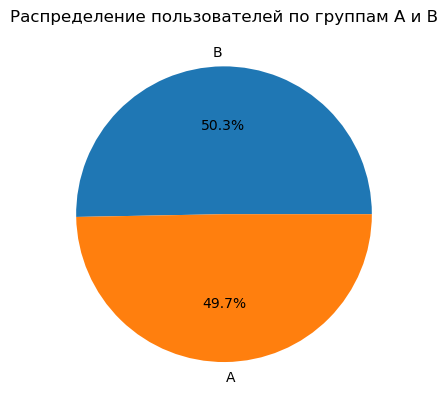

In [54]:
# строим график распределения пользователей
test = participants[participants['ab_test'] == 'interface_eu_test']
dist = test['group'].value_counts()
dist.plot(kind = 'pie', autopct='%1.1f%%')
plt.title('Распределение пользователей по группам А и В')
plt.ylabel('')
plt.show()

В группе А находится 49,7% пользователей, в группе В - 50,3%. Можно сказать, что пользователи распределены равномерно.


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [55]:
# найдем id пользователей, находящихся в тестовой группе interface_eu_test
ids = test['user_id']
ids = list(ids)

In [56]:
# в таблице events оставляем данные только о пользователях из interface_eu_test
events = events[events['user_id'].isin(ids)]

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [57]:
# дата регистрации каждого пользователя
registration = events[events['event_name'] == 'registration'][['user_id', 'event_dt']]

# добавляем к таблице событий дату регистрации каждого пользователя
new_table = pd.merge(events, registration, on = 'user_id', how = 'left')

new_table.head()

,user_id,event_dt_x,event_name,details,event_dt_y
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20


In [58]:
# создаем новый столбец с количеством дней после регистрации
new_table['days_since_registration'] = new_table['event_dt_x'] - new_table['event_dt_y']
new_table.head()

,user_id,event_dt_x,event_name,details,event_dt_y,days_since_registration
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0 days
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0 days
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0 days
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0 days
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0 days


In [59]:
# оставляем только те события, которые были выполнены в течение первых 7 дней после регистрации
new_table = new_table[new_table['days_since_registration'] > '0 days 00:00:00']
new_table = new_table[new_table['days_since_registration'] < '7 days']

In [60]:
# Код ревьюера
(new_table.event_dt_x - new_table.event_dt_y).max()

Timedelta('6 days 23:58:10')

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

Посчитаем необходимый размер выборки с помощью калькулятора Эвана Милера (калькулятора для долевых метрик). 

[Ссылка на калькулятор](https://www.evanmiller.org/ab-testing/sample-size.html)


Будем использовать следующие параметры теста:

- базовый показатель конверсии — 30%,

- mde (минимальный обнаружимый эффект) - 3% в абсолютном значении,

- мощность теста — 80%,

- достоверность теста — 95% (уровень значимости - 5%)

По результатам расчета получилось, что необходимый размер одной выборки - 3692. У нас две выборки, значит нужна выборка размером 3692 * 2 = `7384`.
Проверим, хватает ли у нас данных.

In [61]:
new_table['user_id'].nunique()

9835

Данных достаточно.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [62]:
# добавляем группу пользователя
groups = participants[['user_id', 'group']]
new_table = pd.merge(new_table, groups, on = 'user_id', how = 'left')
new_table.head()

,user_id,event_dt_x,event_name,details,event_dt_y,days_since_registration,group
0,B13A53A1EB2038EE,2020-12-07 00:04:00,login,NaN,2020-12-06 23:58:03,0 days 00:05:57,B
1,4C4BA430AAA820F8,2020-12-07 00:04:30,login,NaN,2020-12-07 00:02:47,0 days 00:01:43,B
2,4B7C59A60FE1DA69,2020-12-07 00:04:30,login,NaN,2020-12-07 00:03:51,0 days 00:00:39,A
3,4C4BA430AAA820F8,2020-12-07 00:05:26,login,NaN,2020-12-07 00:02:47,0 days 00:02:39,B
4,4B7C59A60FE1DA69,2020-12-07 00:05:33,login,NaN,2020-12-07 00:03:51,0 days 00:01:42,A


In [63]:
# общее количество пользователей группы А
total_a = new_table[new_table['group'] == 'A']
count_total_a = total_a['user_id'].nunique()

# общее количество пользователей группы В
total_b = new_table[new_table['group'] == 'B']
count_total_b = total_b['user_id'].nunique()

# общее количество покупателей группы А
purchase_a = total_a[total_a['event_name'] == 'purchase']
count_purchase_a = purchase_a['user_id'].nunique()

# общее количество покупателей группы В
purchase_b = total_b[total_b['event_name'] == 'purchase']
count_purchase_b = purchase_b['user_id'].nunique()

#print(count_total_a, count_total_b, count_purchase_a, count_purchase_b)
print(f'В группе А всего {count_total_a} посетителей, {count_purchase_a} покупателей. Конверсия в покупателя составляет {round(count_purchase_a/count_total_a, 2)}. В группе B всего {count_total_b} посетителей, {count_purchase_b} покупателей. Конверсия составляет {round(count_purchase_b/count_total_b, 2)}')

В группе А всего 4892 посетителей, 1352 покупателей. Конверсия в покупателя составляет 0.28. В группе B всего 4943 посетителей, 1445 покупателей. Конверсия составляет 0.29


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Можно заметить, что в тестовой группе конверсия (0.31) выше на 2%, чем в контрольной (0,29). Осталось проверить, насколько этот результат статистически значим.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Мы будем проверять одностороннюю гипотезу. Сформулируем нулевую и альтернативные гипотезы:

- Нулевая гипотеза: уровень конверсии интернет-магазина статистически значимо не изменится при внедрении нового интерфейса.
- Альтернативная гипотеза: уровень конверсии интернет-магазина увеличится с внедрением нового интерфейса и это изменение статистически значимо.
  
Возьмем уровень значимости 5%.

Для проверки гипотезы будем использовать z-тест пропорций для долевых метрик.

In [64]:
# размеры выборок
n_b, n_a = count_total_b, count_total_a

# число успехов
m_b, m_a = count_purchase_b, count_purchase_a

# доля успехов в каждой группе
p_b, p_a = m_b/n_b, m_a/n_a

#проверяем предпосылку о достаточном количестве данных
if (p_a*n_a>10) and ((1-p_a)*n_a)>10 and (p_b*n_b)>10 and ((1-p_b)*n_b)>10:
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных не выполняется.')
    
# уровень значимости
alpha = 0.05

# z-тест пропорций
stat_ztest, p_value = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative = 'larger')

print(f'p-value: {p_value}')

if p_value<alpha:
    print('Отвергаем нулевую гипотезу. Изменения действительно есть, и они статистически значимы. Новый интерфейс улучшил конверсию.')
else:
    print('Не удалось отвергнуть нулевую гипотезу.')

Предпосылка о достаточном количестве данных выполняется.
p-value: 0.03966682579511055
Отвергаем нулевую гипотезу. Изменения действительно есть, и они статистически значимы. Новый интерфейс улучшил конверсию.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

p-value получился равным 0.011650393391099878. Статистический тест подтвердил гипотезу о том, что уровень конверсии интернет-магазина увеличится с внедрением нового интерфейса и это изменение статистически значимо. Эксперимент можно считать удачным, нововведение можно масштабировать.